Lab 10

TASK # 1

In [5]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

data = {
    'bedrooms': [3, 3, 5, 2, 4],
    'sq_ft': [2000, 2000, 2500, 1500, 2200],
    'age': [19, 15, 24, 21, 10],
    'neighborhood': ['Urban', 'Suburban', 'Urban', 'Rural', 'Suburban'],
    'price': [300000, 300000, 500000, 200000, 400000]
}
df = pd.DataFrame(data)

df['neighborhood'] = df['neighborhood'].astype('category').cat.codes

x = df[['bedrooms', 'sq_ft', 'age', 'neighborhood']]
y = df['price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

predictions = model.predict(x_test)

print("\nPredictions:", predictions)

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("RMSE:", rmse)
print("R2 Score:", r2)
new_house = pd.DataFrame({
    'bedrooms': [3],
    'sq_ft': [1800],
    'age': [8],
    'neighborhood': [1]
})
new_pred = model.predict(new_house)
print("Predicted Price for new house:", new_pred[0])



Predictions: [329141.85965863]
RMSE: 29141.85965863231
R2 Score: nan
Predicted Price for new house: 252790.1873530161


C:\Users\M.TRADERS\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


TASK # 2

In [6]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

data = {
    'word_freq': [6, 2, 18, 3, 14],
    'length': [90, 45, 170, 55, 140],
    'links': [3, 0, 9, 1, 7],
    'is_spam': [1, 0, 1, 0, 1]
}

df = pd.DataFrame(data)

x = df[['word_freq', 'length', 'links']]
y = df['is_spam']
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

DT = DecisionTreeClassifier()
ModelDT = DT.fit(x_train, y_train)

PredictionDT = ModelDT.predict(x_test)

print("Predictions:", PredictionDT)

testingAccDT = accuracy_score(y_test, PredictionDT) * 100
print(f"Testing Accuracy: {testingAccDT:.2f}%")

# Full Evaluation
print("\nClassification Report:")
print(classification_report(y_test, PredictionDT))

new_email = [[11, 125, 5]]

new_prediction = ModelDT.predict(new_email)

if new_prediction[0] == 1:
    print("\nNew Email Prediction: Spam")
else:
    print("\nNew Email Prediction: Not Spam")

Predictions: [0]
Testing Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1


New Email Prediction: Spam


C:\Users\M.TRADERS\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Task # 3

In [7]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
data = {
    'spending': [8000, 1500, 6500, 700, 7200],
    'age': [38, 24, 42, 20, 36],
    'visits': [28, 6, 24, 3, 26],
    'frequency': [14, 3, 11, 1, 13],
    'label': [1, 0, 1, 0, 1]
}

df = pd.DataFrame(data)

x = df[['spending', 'age', 'visits', 'frequency']]
y = df['label']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

svm = SVC(kernel='linear', C=1)
svm.fit(x_train, y_train)

y_pred = svm.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred))

SVM Accuracy: 1.0


Lab Task 11

Task # 1

In [8]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Mall_Customers.csv')

x = df.drop(['CustomerID'], axis=1)

x['Gender'] = x['Gender'].astype('category').cat.codes


km1 = KMeans(n_clusters=5, init='k-means++', random_state=42)
res1 = km1.fit_predict(x)

scaler = StandardScaler()

cols = [c for c in x.columns if c != 'Age']

x_scaled = x.copy()
x_scaled[cols] = scaler.fit_transform(x[cols])

km2 = KMeans(n_clusters=5, init='k-means++', random_state=42)
res2 = km2.fit_predict(x_scaled)


print("Unscaled Results:", res1[:5])
print("Scaled Results:", res2[:5])

Unscaled Results: [2 2 0 2 0]
Scaled Results: [2 2 2 2 1]


Task # 2

In [9]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage': [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
    'fuel_efficiency': [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'maintenance_cost': [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
    'vehicle_type': ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan', 'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}

df = pd.DataFrame(data)

x = df.copy()

x['vehicle_type'] = x['vehicle_type'].astype('category').cat.codes

km1 = KMeans(n_clusters=3, init='k-means++', random_state=42)
res1 = km1.fit_predict(x)

scaler = StandardScaler()

cols = ['vehicle_serial_no', 'mileage', 'fuel_efficiency', 'maintenance_cost']

x_scaled = x.copy()
x_scaled[cols] = scaler.fit_transform(x[cols])

km2 = KMeans(n_clusters=3, init='k-means++', random_state=42)
res2 = km2.fit_predict(x_scaled)

print("Unscaled Results:", res1)
print("Scaled Results:", res2)

Unscaled Results: [2 2 1 0 0 1 2 1 0 1]
Scaled Results: [2 2 1 0 2 1 2 1 0 1]


Task # 3

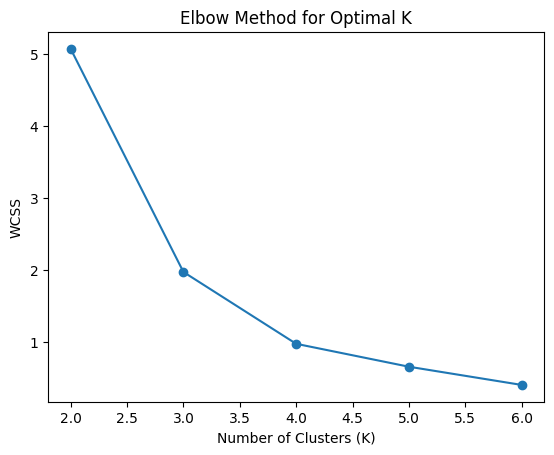


Final Clustered Dataset:
   student_id  cluster
0         101        2
1         102        1
2         103        0
3         104        1
4         105        2
5         106        0
6         107        1
7         108        2


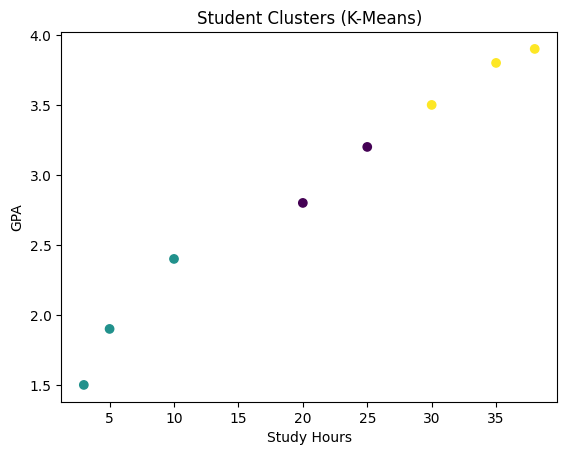

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = {
    'student_id': [101, 102, 103, 104, 105, 106, 107, 108],
    'GPA': [3.8, 2.4, 3.2, 1.9, 3.5, 2.8, 1.5, 3.9],
    'study_hours': [35, 10, 25, 5, 30, 20, 3, 38],
    'attendance_rate': [95, 60, 80, 50, 90, 70, 40, 98]
}
df = pd.DataFrame(data)
x = df[['GPA', 'study_hours', 'attendance_rate']]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
wcss = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2, 7), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['cluster'] = kmeans.fit_predict(x_scaled)
print("\nFinal Clustered Dataset:")
print(df[['student_id', 'cluster']])

plt.scatter(df['study_hours'], df['GPA'], c=df['cluster'], cmap='viridis')
plt.title("Student Clusters (K-Means)")
plt.xlabel("Study Hours")
plt.ylabel("GPA")
plt.show()